<a href="https://colab.research.google.com/github/pankajkumar8709/Machine-Learning-projects/blob/main/Customer_ChurnRate_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np # linear algebra
import pandas as pd # data processing
import matplotlib.pyplot as plt
import seaborn as sns
import plotly as py
import plotly.graph_objs as go
import kagglehub

In [4]:
path=kagglehub.dataset_download("sushmi17/customer-churn-prediction-dataset")

100%|██████████| 262k/262k [00:00<00:00, 45.0MB/s]

Extracting files...


In [5]:
path

'/root/.cache/kagglehub/datasets/sushmi17/customer-churn-prediction-dataset/versions/1'

In [6]:
import os
os.listdir(path)

['Churn_Modelling.csv']

In [8]:
df=pd.read_csv(path+'/Churn_Modelling.csv')

In [9]:
df.sample(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
4312,4313,15720687,Chidubem,576,France,Female,41,4,112609.91,1,0,0,191035.18,1
5376,5377,15602500,Maslova,850,Spain,Male,38,1,146343.98,1,0,1,103902.11,0
8333,8334,15743709,Toomey,683,France,Male,30,4,66190.33,1,1,1,115186.97,0
3688,3689,15662578,Dettmann,679,Germany,Male,35,1,110245.13,1,1,1,178291.09,0
5792,5793,15795186,Leonard,562,France,Male,38,5,0.00,1,1,0,115700.20,0


In [10]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [11]:
df['Geography'].unique()

array(['France', 'Spain', 'Germany'], dtype=object)

In [13]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Geography']=le.fit_transform(df['Geography'])
df['Gender']=le.fit_transform(df['Gender'])

In [14]:
df.sample(5)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
6349,542,0,0,25,7,0.00,2,0,1,82393.08,0
9688,850,0,1,68,5,169445.40,1,1,1,186335.07,0
6856,528,0,1,34,1,125566.90,1,1,1,176763.27,0
3963,607,0,1,31,8,0.00,2,1,1,43196.50,0
1863,731,2,1,25,8,96950.21,1,1,0,97877.92,0


<Axes: xlabel='CreditScore', ylabel='Age'>

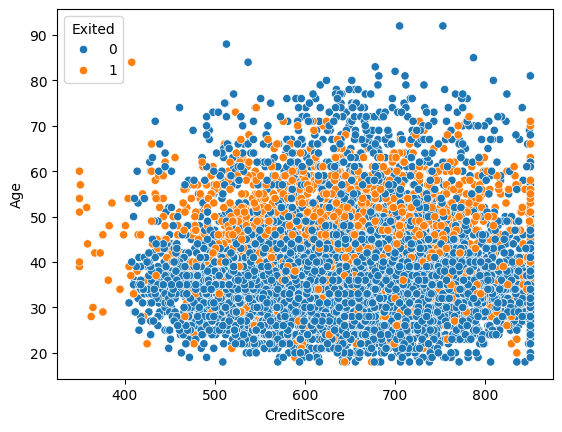

In [17]:
sns.scatterplot(df,x='CreditScore',y='Age',hue='Exited')

<Axes: xlabel='CreditScore', ylabel='Gender'>

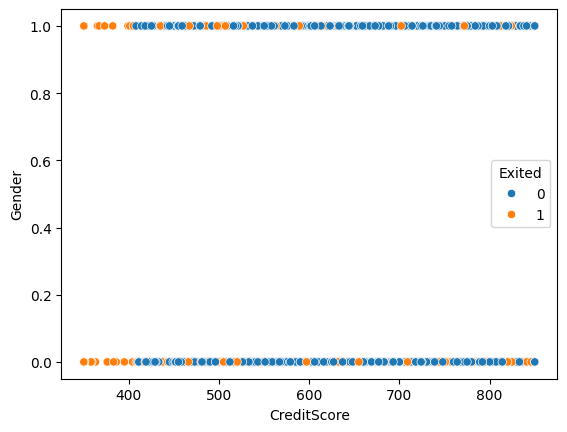

In [15]:
sns.scatterplot(df,x='CreditScore',y='Gender',hue='Exited')

In [21]:
import pandas as pd
import plotly.express as px

# Load dataset
# df = pd.read_csv("Churn_Modelling.csv")

fig = px.scatter_3d(
    df,
    x="Age",
    y="Balance",
    z="CreditScore",
    color="Exited",
    opacity=0.6,
    title="3D Visualization of Customer Churn",
    labels={
        "Age": "Age",
        "Balance": "Balance",
        "CreditScore": "Credit Score",
        "Exited": "Exited"
    }
)

fig.update_layout(
    scene=dict(
        xaxis_title="Age",
        yaxis_title="Balance",
        zaxis_title="Credit Score"
    )
)

fig.show()

<Axes: ylabel='Density'>

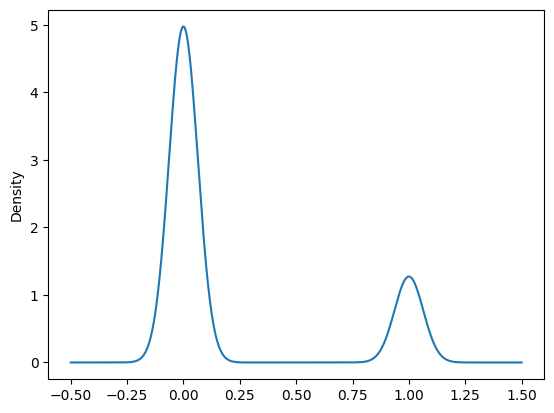

In [24]:
df['Exited'].plot(kind='kde')

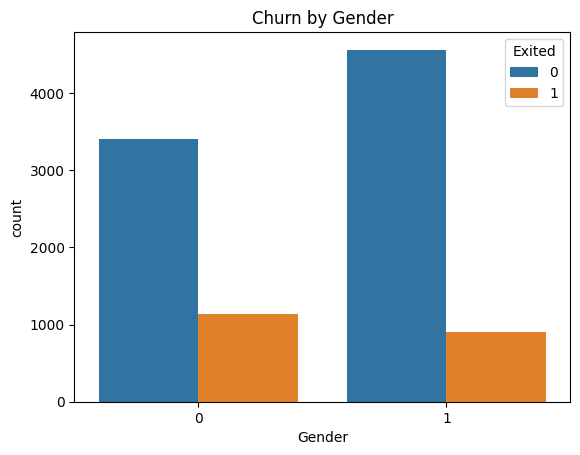

In [25]:
sns.countplot(
    data=df,
    x="Gender",
    hue="Exited"
)

plt.title("Churn by Gender")
plt.show()

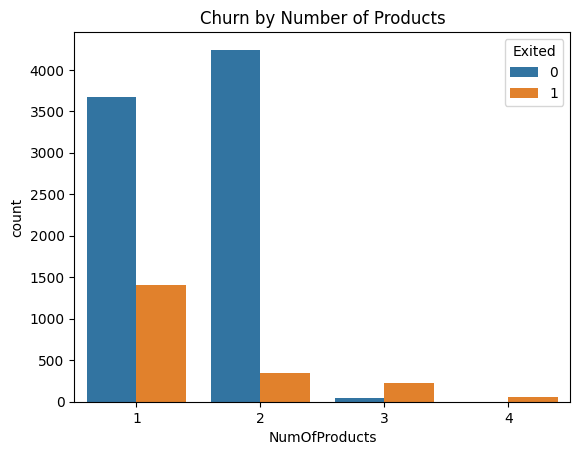

In [26]:
 sns.countplot(
    data=df,
    x="NumOfProducts",
    hue="Exited"
)

plt.title("Churn by Number of Products")
plt.show()

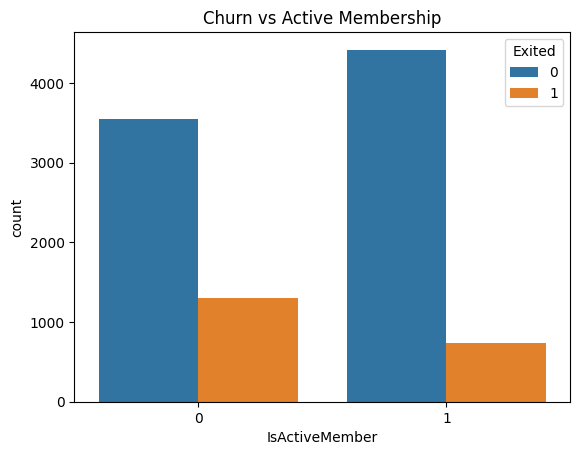

In [27]:
sns.countplot(
    data=df,
    x="IsActiveMember",
    hue="Exited"
)

plt.title("Churn vs Active Membership")
plt.show()

In [28]:
import plotly.express as px

fig = px.scatter_3d(
    df,
    x="Age",
    y="Balance",
    z="CreditScore",
    color="Exited",
    hover_data=[
        "Geography",
        "Gender",
        "Tenure",
        "NumOfProducts",
        "IsActiveMember",
        "EstimatedSalary"
    ],
    opacity=0.6
)

fig.update_layout(
    title="3D Customer Churn Analysis"
)

fig.show()

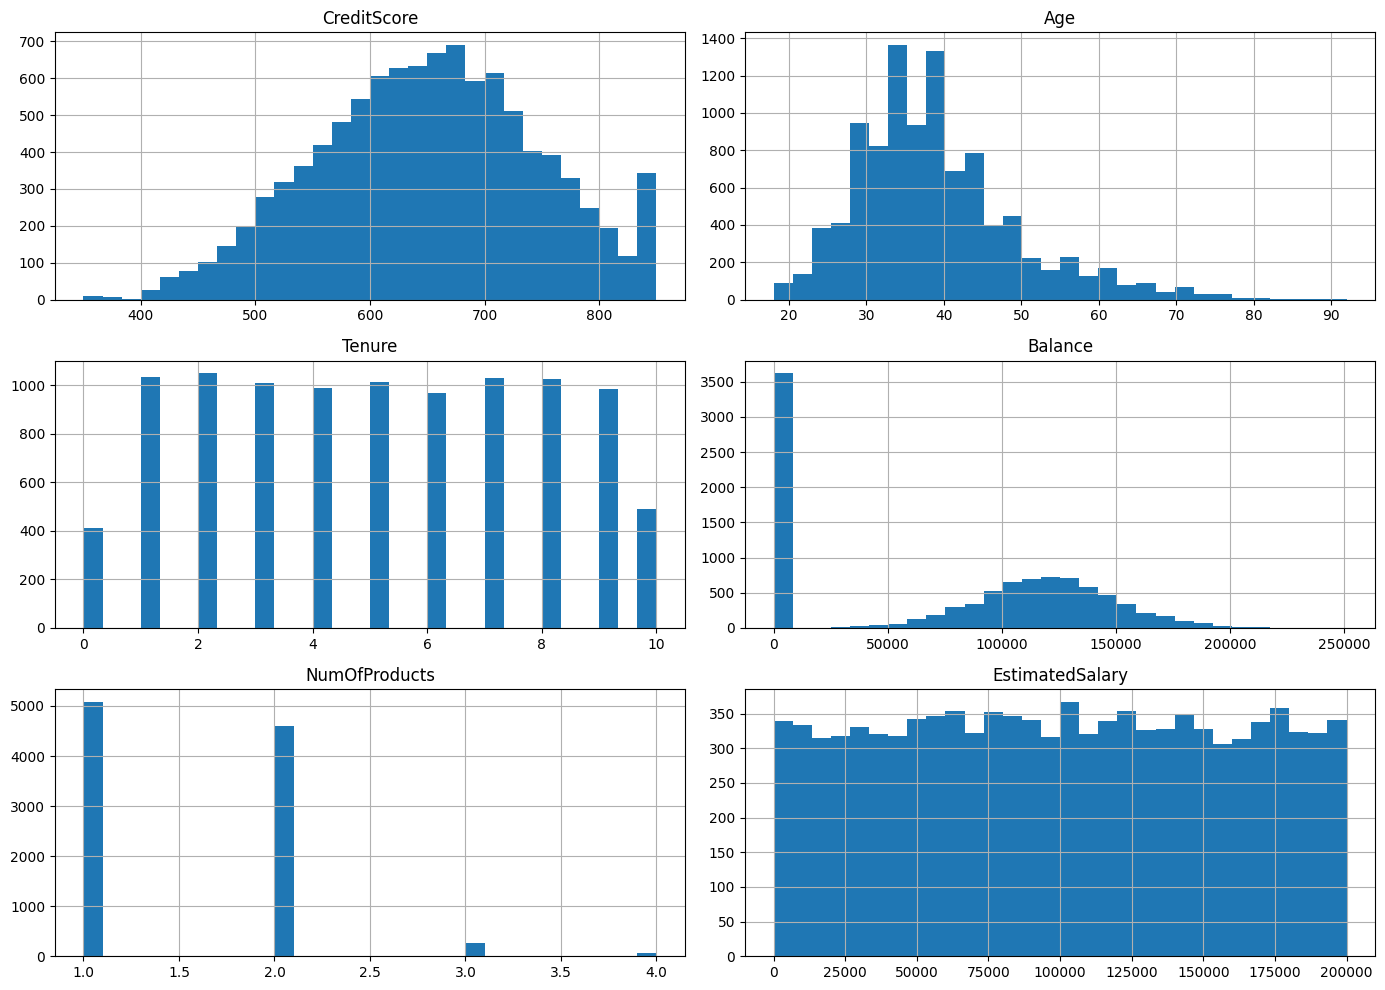

In [29]:
numeric_cols = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary"
]

df[numeric_cols].hist(
    figsize=(14, 10),
    bins=30
)

plt.tight_layout()
plt.show()


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [31]:
x_train,x_test,y_train,y_test=train_test_split(df.drop(columns=['Exited']),df['Exited'],test_size=0.2,random_state=42)

In [45]:
rf=RandomForestClassifier(n_estimators=200,max_depth=20)
rf.fit(x_train,y_train)


RandomForestClassifier(max_depth=20, n_estimators=200)

In [46]:
accuracy_score(y_test,rf.predict(x_test))

0.867

In [47]:
rf=RandomForestClassifier(n_estimators=300,max_depth=30)
rf.fit(x_train,y_train)


RandomForestClassifier(max_depth=30, n_estimators=300)

In [48]:
accuracy_score(y_test,rf.predict(x_test))

0.8705

In [49]:
xbc=XGBClassifier()
xbc.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [50]:
accuracy_score(y_test,xbc.predict(x_test))

0.8565

In [66]:
xbc=XGBClassifier(n_estimators=400,max_depth=3)
xbc.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=400,
              n_jobs=None, num_parallel_tree=None, ...)

In [67]:
accuracy_score(y_test,xbc.predict(x_test))

0.866